In [28]:
#Weighted histograms: coffea env
#Manage the bins
#Add more signal samples

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import json
import boost_histogram as bh
import uproot
from scipy.stats import beta
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [2]:
with open('../configs/sample_configs/signal_2022_Mchi_10_30_50_aEM.json') as file:
    sig_file = json.load(file)

In [3]:
loc0 = sig_file[0]["location"]
sig_root0 = uproot.open(loc0)
sig_root0.keys()
ntuple0 = sig_root0["ntuples/outT"]
# ntuple.keys()
# print (ntuple["genWgt"].array())
# print (sum(ntuple["genWgt"].array()))

In [4]:
loc1 = sig_file[1]["location"]
sig_root1 = uproot.open(loc1)
sig_root1.keys()
ntuple1 = sig_root1["ntuples/outT"]
# ntuple.keys()
# print (ntuple["genWgt"].array())
# print (sum(ntuple["genWgt"].array()))

In [5]:
loc2 = sig_file[2]["location"]
sig_root2 = uproot.open(loc2)
sig_root2.keys()
ntuple2 = sig_root2["ntuples/outT"]
# ntuple.keys()
# print (ntuple["genWgt"].array())
# print (sum(ntuple["genWgt"].array()))

In [6]:
met_trig0 = ntuple0["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
print (met_trig0)
len (met_trig0)

[False, False, False, False, False, False, ... False, False, False, False, True]


64486

In [7]:
met_trig1 = ntuple1["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
print (met_trig1)
len (met_trig1)

[False, False, False, True, True, False, ... False, False, True, False, False, True]


67154

In [8]:
met_trig2 = ntuple2["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
print (met_trig2)
len (met_trig2)

[True, True, False, False, True, False, ... False, True, True, False, True, False]


69068

In [9]:
#Kinematic cut applied:

PFMET_pt0=ntuple0["PFMET_pt"].array()

CaloMET_pt0=ntuple0["CaloMET_pt"].array()
diff0 = abs(PFMET_pt0-CaloMET_pt0)

r0 = diff0/(CaloMET_pt0)
cut0 = (r0 <0.5)

print (cut0)
len (cut0)

[False, True, False, True, False, False, ... True, True, True, False, True, True]


64486

In [10]:
#Kinematic cut applied:

PFMET_pt1=ntuple1["PFMET_pt"].array()

CaloMET_pt1=ntuple1["CaloMET_pt"].array()
diff1 = abs(PFMET_pt1-CaloMET_pt1)

r1 = diff1/(CaloMET_pt1)
cut1 = (r1 <0.5)

print (cut1)
len (cut1)

[True, True, True, True, True, True, True, ... True, False, True, True, True, True]


67154

In [11]:
#Kinematic cut applied:

PFMET_pt2=ntuple2["PFMET_pt"].array()

CaloMET_pt2=ntuple2["CaloMET_pt"].array()
diff2 = abs(PFMET_pt2-CaloMET_pt2)

r2 = diff2/(CaloMET_pt2)
cut2 = (r2 <0.5)

print (cut2)
len (cut2)

[True, True, True, True, False, True, True, ... True, True, True, True, True, True]


69068

In [12]:
bins = np.linspace(0, 600, 60)  
den0 = PFMET_pt0[cut0]
num0 = PFMET_pt0[(cut0) & (met_trig0)]
print (num0)

[147, 154, 175, 170, 148, 183, 132, 353, ... 184, 246, 157, 138, 142, 168, 180, 177]


In [13]:
bins = np.linspace(0, 600, 60)  
den1 = PFMET_pt1[cut1]
num1 = PFMET_pt1[(cut1) & (met_trig1)]
print (num1)

[173, 205, 140, 183, 213, 170, 125, 127, ... 152, 208, 163, 296, 170, 156, 141, 186]


In [15]:
bins = np.linspace(0, 600, 60)  
den2 = PFMET_pt2[cut2]
num2 = PFMET_pt2[(cut2) & (met_trig2)]
print (num2)

[109, 206, 221, 292, 286, 313, 131, 350, ... 224, 139, 118, 185, 407, 273, 183, 170]


[   0    0    0    0    0    2    6   22   50  107  287  534  947 1302
 1525 1512 1336 1224  965  771  625  489  381  295  244  214  166  132
  115   99   80   56   44   51   60   35   35   39   32   21   17   16
   14   12    7   16   16    7    8    4    8    5    4    5    2    0
    2    3    0]
[   1   24  122  314  697 1415 2301 3603 4661 5507 5586 5427 4647 3922
 2955 2385 1750 1418 1053  809  646  497  383  298  246  215  167  132
  116   99   80   56   45   51   60   35   35   39   32   21   17   16
   14   12    8   16   16    7    8    4    8    5    4    5    2    0
    2    3    0]


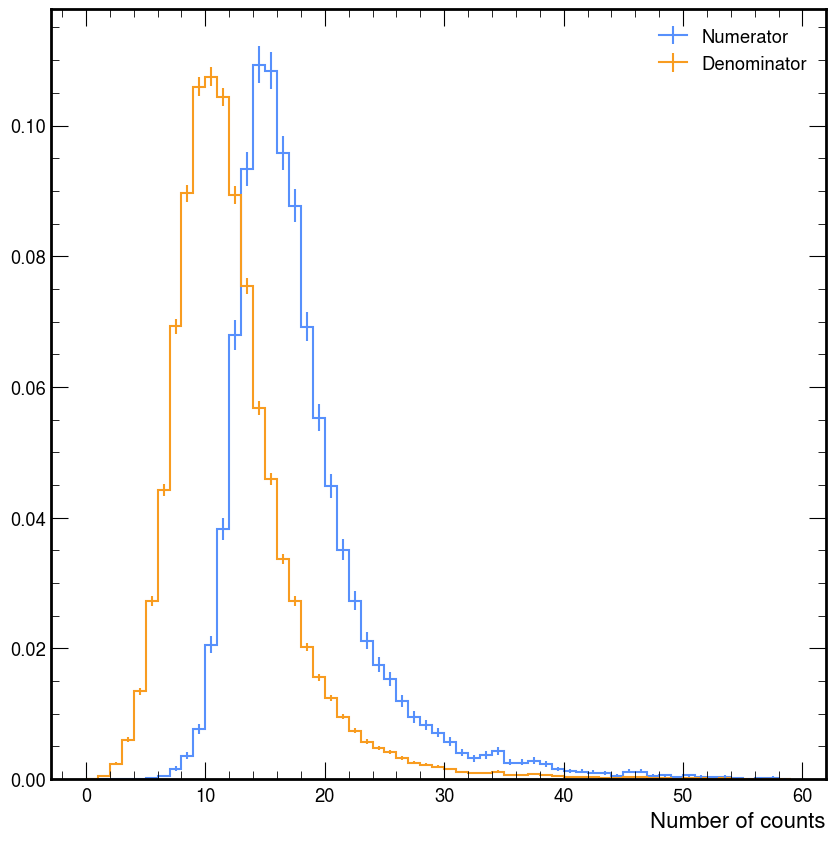

In [17]:
numerator0, bins_num0 = np.histogram(num0, bins)
print (numerator0)
denominator0, bins_den0  = np.histogram(den0, bins)
print (denominator0)

fig, ax = plt.subplots()
mplhep.histplot(numerator0, yerr = True, density = True, label = "Numerator")
mplhep.histplot(denominator0, yerr = True, density = True, label = "Denominator")
ax.set_xlabel("Number of counts")
ax.legend()
plt.savefig("Number of counts.png")

[   0    0    0    0    1    1    8   15   40  119  296  555 1018 1475
 1782 1766 1740 1547 1267 1060  844  692  592  456  361  303  242  206
  167  151  124  116   97   77   54   48   38   39   31   30   30   24
   16   22   16    9   14    4   12    9    6    8    5    3    4    1
    1    1    1]
[   1   27  102  300  666 1170 2112 3194 4267 5171 5432 5331 4723 4100
 3366 2663 2216 1751 1366 1103  868  698  596  458  362  304  242  206
  169  151  124  116   98   77   54   48   38   39   31   30   30   24
   16   22   16    9   14    4   12    9    6    8    5    3    4    1
    1    1    1]


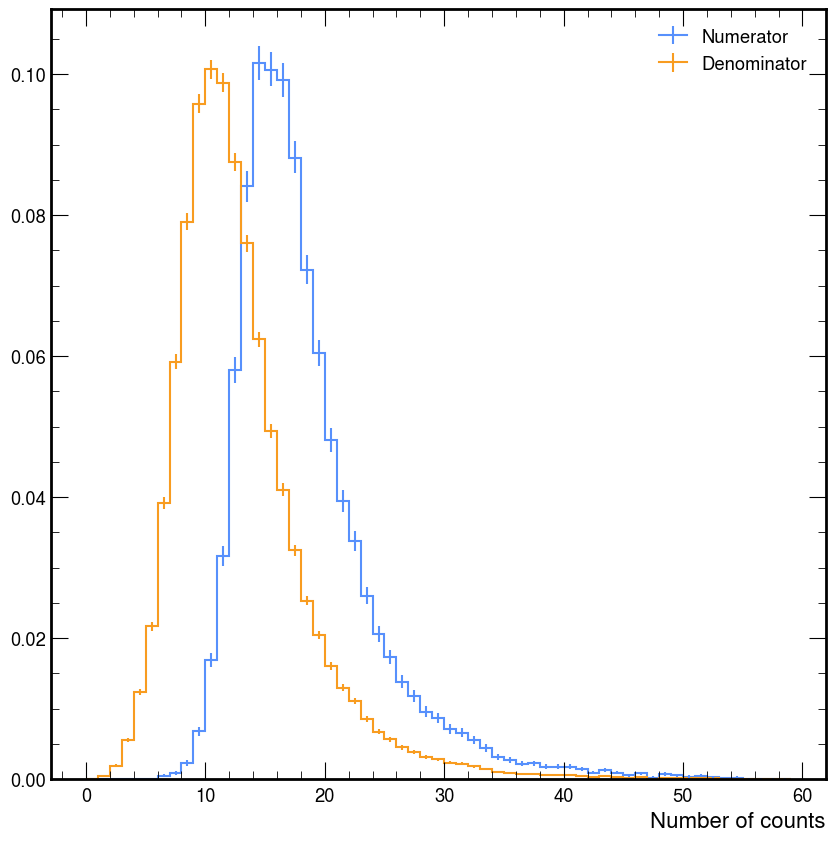

In [18]:
numerator1, bins_num1 = np.histogram(num1, bins)
print (numerator1)
denominator1, bins_den1  = np.histogram(den1, bins)
print (denominator1)

fig, ax = plt.subplots()
mplhep.histplot(numerator1, yerr = True, density = True, label = "Numerator")
mplhep.histplot(denominator1, yerr = True, density = True, label = "Denominator")
ax.set_xlabel("Number of counts")
ax.legend()
plt.savefig("Number of counts.png")

[   0    0    0    0    1    1    8   15   40  119  296  555 1018 1475
 1782 1766 1740 1547 1267 1060  844  692  592  456  361  303  242  206
  167  151  124  116   97   77   54   48   38   39   31   30   30   24
   16   22   16    9   14    4   12    9    6    8    5    3    4    1
    1    1    1]
[   0   13   81  236  547 1040 1816 2861 3710 4539 4997 4994 4673 4200
 3544 3085 2525 2087 1713 1440 1265 1003  786  676  557  485  415  347
  267  232  209  143  172  136  140  112   86   83   64   50   54   49
   42   27   31   30   32   16   19   12   14    9   11   10    9    7
    6    6    6]


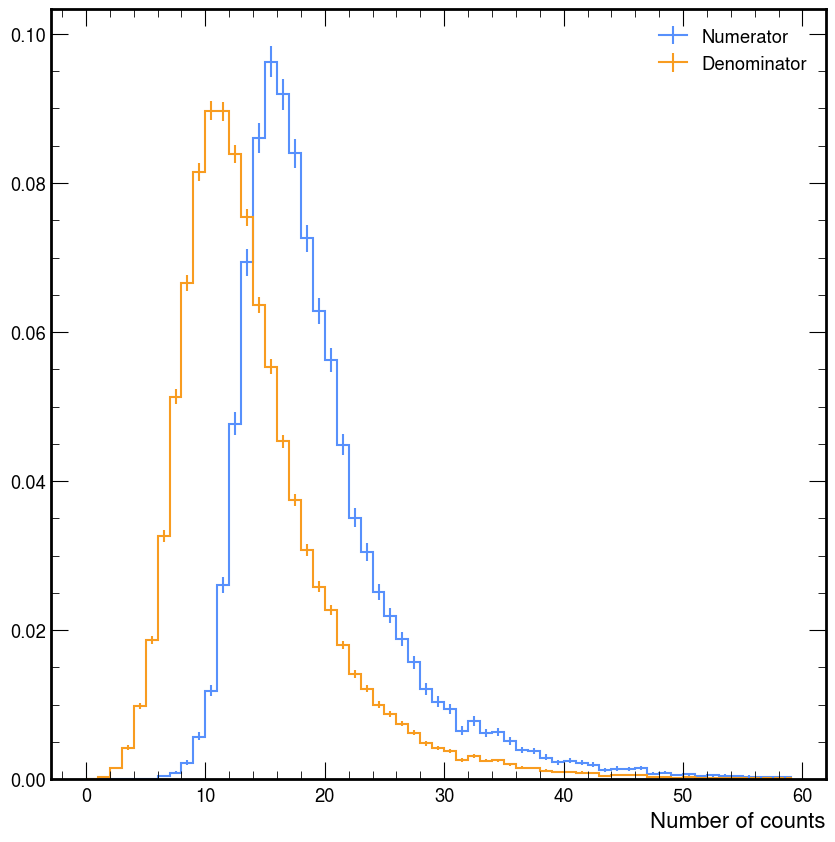

In [19]:
numerator2, bins_num2 = np.histogram(num2, bins)
print (numerator1)
denominator2, bins_den2  = np.histogram(den2, bins)
print (denominator2)

fig, ax = plt.subplots()
mplhep.histplot(numerator2, yerr = True, density = True, label = "Numerator")
mplhep.histplot(denominator2, yerr = True, density = True, label = "Denominator")
ax.set_xlabel("Number of counts")
ax.legend()
plt.savefig("Number of counts.png")

In [20]:
index_removal0 = []
print ("Denominator0:", denominator0)
print ("Numerator0:", numerator0)
for (index0, value0) in enumerate(denominator0):
    if (value0 == 0):
        index_removal0.append(index0)

print (index_removal0)
den0 = np.delete(denominator0, index_removal0)
print ("den0:", den0)
num0  = np.delete(numerator0, index_removal0)
print ("num0:", num0)
print (len(numerator0))
print (len(denominator0))
print (bins_num0)
bins_num_removed0 = np.delete(bins_num0, index_removal0)
print (bins_num_removed0)

Denominator0: [   1   24  122  314  697 1415 2301 3603 4661 5507 5586 5427 4647 3922
 2955 2385 1750 1418 1053  809  646  497  383  298  246  215  167  132
  116   99   80   56   45   51   60   35   35   39   32   21   17   16
   14   12    8   16   16    7    8    4    8    5    4    5    2    0
    2    3    0]
Numerator0: [   0    0    0    0    0    2    6   22   50  107  287  534  947 1302
 1525 1512 1336 1224  965  771  625  489  381  295  244  214  166  132
  115   99   80   56   44   51   60   35   35   39   32   21   17   16
   14   12    7   16   16    7    8    4    8    5    4    5    2    0
    2    3    0]
[55, 58]
den0: [   1   24  122  314  697 1415 2301 3603 4661 5507 5586 5427 4647 3922
 2955 2385 1750 1418 1053  809  646  497  383  298  246  215  167  132
  116   99   80   56   45   51   60   35   35   39   32   21   17   16
   14   12    8   16   16    7    8    4    8    5    4    5    2    2
    3]
num0: [   0    0    0    0    0    2    6   22   50  107  287  534

In [21]:
index_removal1 = []
print ("Denominator1:", denominator1)
print ("Numerator1:", numerator1)
for (index1, value1) in enumerate(denominator1):
    if (value1 == 0):
        index_removal1.append(index1)

print (index_removal1)
den1 = np.delete(denominator1, index_removal1)
print ("den1:", den1)
num1  = np.delete(numerator1, index_removal1)
print ("num1:", num1)
print (len(numerator1))
print (len(denominator1))
print (bins_num1)
bins_num_removed1 = np.delete(bins_num1, index_removal1)
print (bins_num_removed1)

Denominator1: [   1   27  102  300  666 1170 2112 3194 4267 5171 5432 5331 4723 4100
 3366 2663 2216 1751 1366 1103  868  698  596  458  362  304  242  206
  169  151  124  116   98   77   54   48   38   39   31   30   30   24
   16   22   16    9   14    4   12    9    6    8    5    3    4    1
    1    1    1]
Numerator1: [   0    0    0    0    1    1    8   15   40  119  296  555 1018 1475
 1782 1766 1740 1547 1267 1060  844  692  592  456  361  303  242  206
  167  151  124  116   97   77   54   48   38   39   31   30   30   24
   16   22   16    9   14    4   12    9    6    8    5    3    4    1
    1    1    1]
[]
den1: [   1   27  102  300  666 1170 2112 3194 4267 5171 5432 5331 4723 4100
 3366 2663 2216 1751 1366 1103  868  698  596  458  362  304  242  206
  169  151  124  116   98   77   54   48   38   39   31   30   30   24
   16   22   16    9   14    4   12    9    6    8    5    3    4    1
    1    1    1]
num1: [   0    0    0    0    1    1    8   15   40  119  296 

In [22]:
index_removal2 = []
print ("Denominator2:", denominator2)
print ("Numerator2:", numerator2)
for (index2, value2) in enumerate(denominator2):
    if (value2 == 0):
        index_removal2.append(index2)

print (index_removal2)
den2 = np.delete(denominator2, index_removal2)
print ("den2:", den2)
num2  = np.delete(numerator2, index_removal2)
print ("num2:", num2)
print (len(numerator2))
print (len(denominator2))
print (bins_num2)
bins_num_removed2 = np.delete(bins_num2, index_removal2)
print (bins_num_removed2)

Denominator2: [   0   13   81  236  547 1040 1816 2861 3710 4539 4997 4994 4673 4200
 3544 3085 2525 2087 1713 1440 1265 1003  786  676  557  485  415  347
  267  232  209  143  172  136  140  112   86   83   64   50   54   49
   42   27   31   30   32   16   19   12   14    9   11   10    9    7
    6    6    6]
Numerator2: [   0    0    0    0    0    0    9   19   49  126  262  575 1054 1532
 1900 2127 2030 1855 1603 1388 1243  991  775  673  555  484  414  346
  267  230  208  143  172  136  140  112   86   83   64   50   54   49
   42   27   31   30   32   16   19   12   14    9   11   10    9    7
    6    6    6]
[0]
den2: [  13   81  236  547 1040 1816 2861 3710 4539 4997 4994 4673 4200 3544
 3085 2525 2087 1713 1440 1265 1003  786  676  557  485  415  347  267
  232  209  143  172  136  140  112   86   83   64   50   54   49   42
   27   31   30   32   16   19   12   14    9   11   10    9    7    6
    6    6]
num2: [   0    0    0    0    0    9   19   49  126  262  575 1054

In [24]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc

efficiency0, unc_eff0 = eff_determine_unc(num0, den0)
print (efficiency0)
yerr0 = [unc_eff0[0], unc_eff0[1]]


efficiency1, unc_eff1 = eff_determine_unc(num1, den1)
print (efficiency1)
yerr1 = [unc_eff1[0], unc_eff1[1]]


efficiency2, unc_eff2 = eff_determine_unc(num2, den2)
print (efficiency2)
yerr2 = [unc_eff2[0], unc_eff2[1]]


[0.         0.         0.         0.         0.         0.00141343
 0.00260756 0.00610602 0.01072731 0.01942982 0.05137845 0.0983969
 0.20378739 0.33197348 0.51607445 0.63396226 0.76342857 0.86318759
 0.91642925 0.95302843 0.96749226 0.98390342 0.99477807 0.98993289
 0.99186992 0.99534884 0.99401198 1.         0.99137931 1.
 1.         1.         0.97777778 1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.875      1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.        ]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.50150150e-03 8.54700855e-04 3.78787879e-03 4.69630557e-03
 9.37426764e-03 2.30129569e-02 5.44918999e-02 1.04108047e-01
 2.15540970e-01 3.59756098e-01 5.29411765e-01 6.63161848e-01
 7.85198556e-01 8.83495146e-01 9.27525622e-01 9.61015413e-01
 9.72350230e-01 9.91404011e-01 9.93288591e-01 9.95633188e-01
 9.97237569e-01 9.96710526e-01 1.0000

bins_x0: [  5.08474576  15.25423729  25.42372881  35.59322034  45.76271186
  55.93220339  66.10169492  76.27118644  86.44067797  96.61016949
 106.77966102 116.94915254 127.11864407 137.28813559 147.45762712
 157.62711864 167.79661017 177.96610169 188.13559322 198.30508475
 208.47457627 218.6440678  228.81355932 238.98305085 249.15254237
 259.3220339  269.49152542 279.66101695 289.83050847 300.
 310.16949153 320.33898305 330.50847458 340.6779661  350.84745763
 361.01694915 371.18644068 381.3559322  391.52542373 401.69491525
 411.86440678 422.03389831 432.20338983 442.37288136 452.54237288
 462.71186441 472.88135593 483.05084746 493.22033898 503.38983051
 513.55932203 523.72881356 533.89830508 544.06779661 559.3220339
 574.57627119 589.83050847]


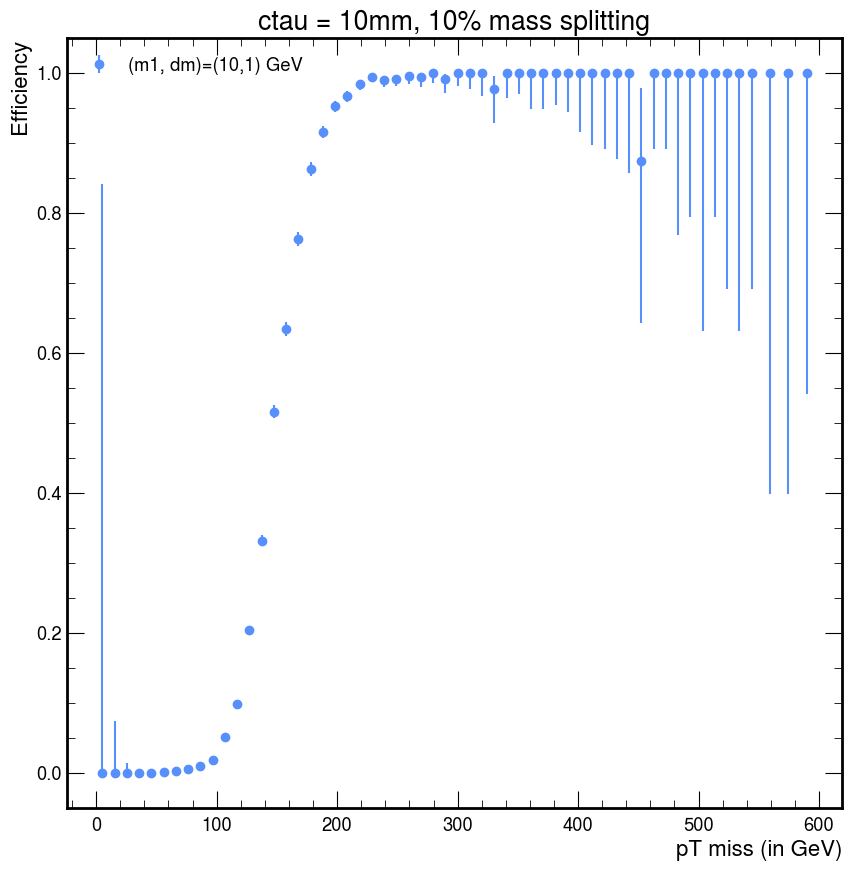

In [26]:
bins_x0 = (bins_num_removed0[:-1] + bins_num_removed0[1:])*(0.5)
#print("bins_x0:",bins_x0)
plt.errorbar(bins_x0, efficiency0, yerr0 , fmt='o', label = '(m1, dm)=(10,1) GeV')
plt.xlabel("pT miss (in GeV)")
plt.ylabel("Efficiency")
plt.title ("ctau = 10mm, 10% mass splitting")
plt.legend()
plt.savefig("Eff_latest0.png")


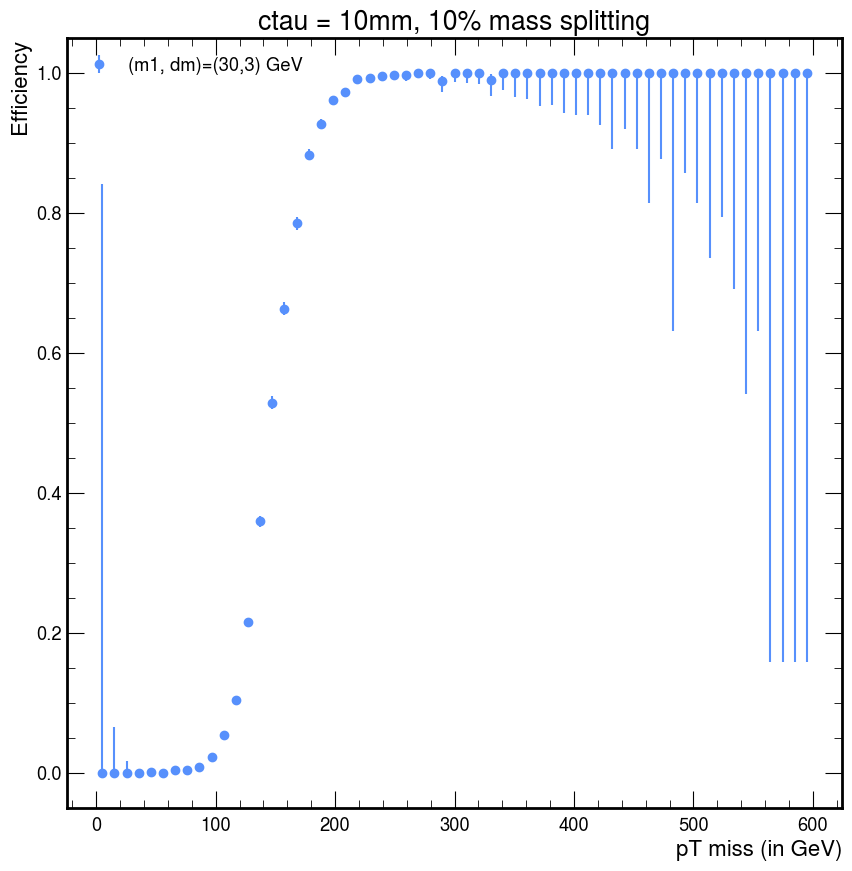

In [29]:
bins_x1 = (bins_num_removed1[:-1] + bins_num_removed1[1:])*(0.5)
#print("bins_x1:",bins_x1)
plt.errorbar(bins_x1, efficiency1, yerr1 , fmt='o', label = '(m1, dm)=(30,3) GeV')
plt.xlabel("pT miss (in GeV)")
plt.ylabel("Efficiency")
plt.title ("ctau = 10mm, 10% mass splitting")
plt.legend()
plt.savefig("Eff_latest1.png")


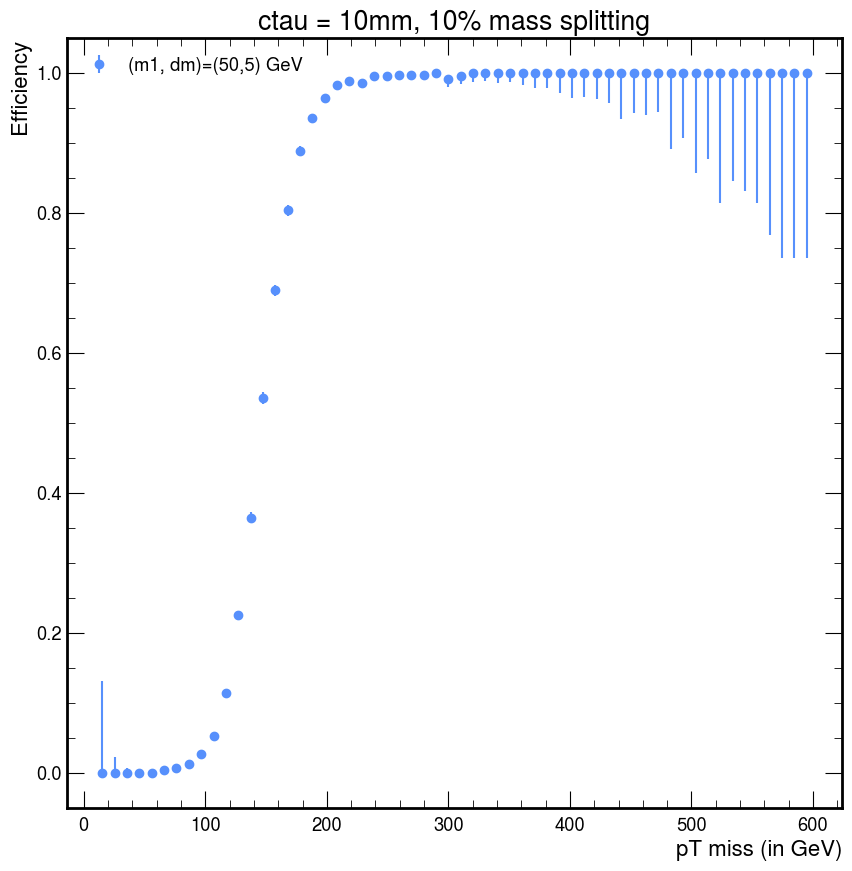

In [30]:
bins_x2 = (bins_num_removed2[:-1] + bins_num_removed2[1:])*(0.5)
#print("bins_x2:",bins_x2)
plt.errorbar(bins_x2, efficiency2, yerr2 , fmt='o', label = '(m1, dm)=(50,5) GeV')
plt.xlabel("pT miss (in GeV)")
plt.ylabel("Efficiency")
plt.title ("ctau = 10mm, 10% mass splitting")
plt.legend()
plt.savefig("Eff_latest2.png")


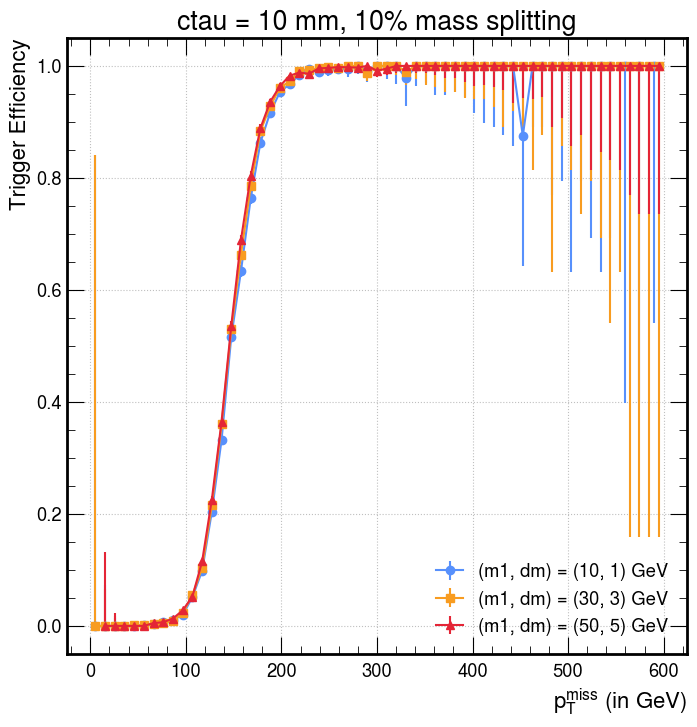

In [35]:

# Create one figure and one set of axes
plt.figure(figsize=(8,8))

# Plot all three datasets on the same canvas
plt.errorbar((bins_num_removed0[:-1] + bins_num_removed0[1:]) * 0.5, efficiency0, yerr0,
             fmt='o-', label='(m1, dm) = (10, 1) GeV')
plt.errorbar((bins_num_removed1[:-1] + bins_num_removed1[1:]) * 0.5, efficiency1, yerr1,
             fmt='s-', label='(m1, dm) = (30, 3) GeV')
plt.errorbar((bins_num_removed2[:-1] + bins_num_removed2[1:]) * 0.5, efficiency2, yerr2,
             fmt='^-', label='(m1, dm) = (50, 5) GeV')

# Labels, title, legend, and style
plt.xlabel("$p_{T}^{miss}$ (in GeV)")
plt.ylabel("Trigger Efficiency")
plt.title("ctau = 10 mm, 10% mass splitting")
plt.legend()
plt.grid(True)

# Save combined plot
plt.savefig("Eff_all_combined.png", dpi=300, bbox_inches='tight')
plt.show()
